# Ajout des bibliothèques nécessaires

In [113]:
# Fichiers et données
import os
import glob
import json
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Représentation textuelle
from sklearn.feature_extraction.text import TfidfVectorizer

# Modèles
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Pipelines et validation
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_validate

# Évaluation
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Toutes les bibliothèques sont chargées.")

Toutes les bibliothèques sont chargées.


In [114]:
REMPLACEMENTS_APOSTROPHES = {
    # ========================================================
    # Locutions longues : à traiter avant les formes courtes
    # ========================================================
    "lorsquil": "lorsqu'il",
    "lorsquils": "lorsqu'ils",
    "lorsquon": "lorsqu'on",
    "lorsquune": "lorsqu'une",
    "lorsquun": "lorsqu'un",
    "lorsquelle": "lorsqu'elle",
    "lorsquelles": "lorsqu'elles",

    "puisquil": "puisqu'il",
    "puisquils": "puisqu'ils",
    "puisquon": "puisqu'on",
    "puisquune": "puisqu'une",
    "puisquun": "puisqu'un",
    "puisquelle": "puisqu'elle",
    "puisquelles": "puisqu'elles",

    "quoiquil": "quoiqu'il",
    "quoiquils": "quoiqu'ils",
    "quoiquon": "quoiqu'on",
    "quoiquelle": "quoiqu'elle",

    "jusquil": "jusqu'il",
    "jusquils": "jusqu'ils",
    "jusquon": "jusqu'on",
    "jusquune": "jusqu'une",
    "jusquun": "jusqu'un",
    "jusquelle": "jusqu'elle",
    "jusquelles": "jusqu'elles",
    "jusquà": "jusqu'à",

    # ========================================================
    # Contractions avec c'
    # ========================================================
    "cest": "c'est",
    "cétait": "c'était",
    "cétaient": "c'étaient",
    "cétant": "c'étant",
    "cen": "c'en",

    # ========================================================
    # Contractions avec s'
    # ========================================================
    "sest": "s'est",
    "sétait": "s'était",
    "sétaient": "s'étaient",
    "sétant": "s'étant",
    "sen": "s'en",
    "sy": "s'y",
    "sil": "s'il",
    "sils": "s'ils",

    # ========================================================
    # Contractions avec n'
    # ========================================================
    "nest": "n'est",
    "nétait": "n'était",
    "nétaient": "n'étaient",
    "navait": "n'avait",
    "navaient": "n'avaient",
    "naurait": "n'aurait",
    "nauraient": "n'auraient",
    "naura": "n'aura",
    "nauront": "n'auront",
    "na": "n'a",
    "nont": "n'ont",
    "nen": "n'en",
    "ny": "n'y",
    "navoir": "n'avoir",
    "nêtre": "n'être",
    "nai": "n'ai",
    "navez": "n'avez",

    # ========================================================
    # Contractions avec j'
    # ========================================================
    "jai": "j'ai",
    "javais": "j'avais",
    "jétais": "j'étais",
    "jaurais": "j'aurais",
    "jaurai": "j'aurai",
    "jaime": "j'aime",
    "jallais": "j'allais",
    "jignore": "j'ignore",
    "jentends": "j'entends",
    "jen": "j'en",
    "jy": "j'y",

    # ========================================================
    # Contractions avec qu'
    # ========================================================
    "quest": "qu'est",
    "quil": "qu'il",
    "quils": "qu'ils",
    "quon": "qu'on",
    "quun": "qu'un",
    "quune": "qu'une",
    "quà": "qu'à",
    "quen": "qu'en",


    # ========================================================
    # Contractions avec d'
    # ========================================================
    "dun": "d'un",
    "delle": "d'elle",
    "delles": "d'elles",
    "deux": "d'eux",
    "dêtre": "d'être",
    "davoir": "d'avoir",
    "dabord": "d'abord",
    "dailleurs": "d'ailleurs",
    "daprès": "d'après",
    "daccord": "d'accord",
    "davance": "d'avance",
    "davantage": "davantage",  # pas d'apostrophe
    "doù": "d'où",
    "dautres": "d'autres",

    # ========================================================
    # Contractions avec l'
    # ========================================================
    "labbé": "l'abbé",
    "lair": "l'air",
    "lâme": "l'âme",
    "lami": "l'ami",
    "lamie": "l'amie",
    "lamour": "l'amour",
    "largent": "l'argent",
    "lautre": "l'autre",
    "lun": "l'un",
    "lune": "l'une",
    "lheure": "l'heure",
    "lhomme": "l'homme",
    "lhonneur": "l'honneur",
    "lhistoire": "l'histoire",
    "lhôtel": "l'hôtel",
    "léglise": "l'église",
    "lépoque": "l'époque",
    "lenfant": "l'enfant",
    "lendroit": "l'endroit",
    "lentrée": "l'entrée",
    "lintérieur": "l'intérieur",
    "lidée": "l'idée",
    "lombre": "l'ombre",
    "loeil": "l'œil",
    "lœil": "l'œil",

    # ========================================================
    # Locutions courantes
    # ========================================================
    "aujourdhui": "aujourd'hui",
    "presquun": "presqu'un",
    "presquune": "presqu'une",
    "quelquun": "quelqu'un",
    "quelquune": "quelqu'une",

    # ========================================================
    # Verbes pronominaux fréquemment rencontrés
    # ========================================================
    "sécria": "s'écria",
    "sécriait": "s'écriait",
    "sécrièrent": "s'écrièrent",
    "saperçut": "s'aperçut",
    "sapercevait": "s'apercevait",
    "sapprocha": "s'approcha",
    "sapprochait": "s'approchait",
    "sarrêta": "s'arrêta",
    "sarrêtait": "s'arrêtait",
    "sassit": "s'assit",
    "sétendit": "s'étendit",
    "séloigna": "s'éloigna",
    "séloignait": "s'éloignait",
    
    # m'
    "men": "m'en",
    "mavez": "m'avez",

    # l'
    "lon": "l'on",
    "lai": "l'ai",
    "lavait": "l'avait",
    "leau": "l'eau",
    "lesprit": "l'esprit",
    "lescalier": "l'escalier",
    "létudiant": "l'étudiant",

    # jusqu'
    "jusquau": "jusqu'au",
    "jusquaux": "jusqu'aux",
}

def adapter_casse(forme_originale, remplacement):
    """Conserve approximativement la casse du mot d'origine."""

    if forme_originale.isupper():
        return remplacement.upper()

    if forme_originale[0].isupper():
        return remplacement[0].upper() + remplacement[1:]

    return remplacement


def restaurer_apostrophes(texte):
    """Restaure certaines apostrophes supprimées avec une forte confiance."""

    remplacements_tries = sorted(
        REMPLACEMENTS_APOSTROPHES.items(),
        key=lambda element: len(element[0]),
        reverse=True
    )

    for forme_nettoyee, forme_corrigee in remplacements_tries:
        motif = rf"\b{re.escape(forme_nettoyee)}\b"

        texte = re.sub(
            motif,
            lambda correspondance: adapter_casse(
                correspondance.group(0),
                forme_corrigee
            ),
            texte,
            flags=re.IGNORECASE
        )

    return texte

## Segmentation des fichiers en paquets de 3 phrases

In [115]:
def segmenter_en_paquets(texte, taille_paquet=3):
    lignes = texte.splitlines()
    lignes = [ligne.strip() for ligne in lignes if ligne.strip()]

    paquets = []

    for i in range(0, len(lignes), taille_paquet):
        paquet = " ".join(lignes[i:i + taille_paquet])

        if paquet:
            paquets.append(paquet)

    return paquets


def determiner_label(nom_fichier):
    if nom_fichier.endswith("clean.txt"):
        return "Zola"

    return "naturaliste"


def construire_dataframe(liste_fichiers):
    donnees = []

    for chemin_fichier in liste_fichiers:
        nom_fichier = os.path.basename(chemin_fichier)
        label = determiner_label(nom_fichier)

        with open(chemin_fichier, "r", encoding="utf-8") as fichier:
            texte = fichier.read()

        # Restauration appliquée aux deux corpus
        texte = restaurer_apostrophes(texte)

        blocs = segmenter_en_paquets(
            texte,
            taille_paquet=3
        )

        for bloc in blocs:
            donnees.append({
                "texte": bloc,
                "label": label,
                "source": nom_fichier
            })

    return pd.DataFrame(donnees)


chemin_dossier = "Z_vs_N"

liste_fichiers = sorted(
    glob.glob(
        os.path.join(chemin_dossier, "*.txt")
    )
)

print(f"Nombre de fichiers trouvés : {len(liste_fichiers)}")

random.seed(1)
random.shuffle(liste_fichiers)

liste_train = liste_fichiers[:40]
liste_test = liste_fichiers[40:]

df_train = construire_dataframe(liste_train)
df_test = construire_dataframe(liste_test)

print("\nTRAIN")
print(df_train["label"].value_counts())
print("Nombre d'œuvres :", df_train["source"].nunique())

print("\nTEST")
print(df_test["label"].value_counts())
print("Nombre d'œuvres :", df_test["source"].nunique())

Nombre de fichiers trouvés : 49

TRAIN
label
Zola           36820
naturaliste    25492
Name: count, dtype: int64
Nombre d'œuvres : 40

TEST
label
Zola           9518
naturaliste    5060
Name: count, dtype: int64
Nombre d'œuvres : 9


In [116]:
print("Textes dans le train")
print(len(df_train))

sources_par_label = (
    df_train.groupby("label")["source"]
      .apply(lambda x: x.dropna().unique().tolist())
)

print("-" * 30)
print("Sources par label :")

for label, sources in sources_par_label.items():
    print(f"\n{label} :")
    for source in sources:
        print(f"  - {source}")
        
print("\n\n\nTextes dans le test)")
print(len(df_test))
        
sources_par_label = (
    df_test.groupby("label")["source"]
      .apply(lambda x: x.dropna().unique().tolist())
)

print("-" * 30)
print("Sources par label :")

for label, sources in sources_par_label.items():
    print(f"\n{label} :")
    for source in sources:
        print(f"  - {source}")

Textes dans le train
62312
------------------------------
Sources par label :

Zola :
  - 1873_3_Le_ventre_de_Paris._clean.txt
  - 1888_16_Le_reve._clean.txt
  - 1882_10_Pot-bouille._clean.txt
  - 1876_6_Son_Excellence_Eugene_Rougon._clean.txt
  - 1887_15_La_terre._clean.txt
  - 1884_12_La_joie_de_vivre._clean.txt
  - 1893_20_Le_docteur_Pascal._clean.txt
  - 1885_13_Germinal._clean.txt
  - 1883_11_Au_Bonheur_des_dames._clean.txt
  - 1874_4_La_conquete_de_Plassans._clean.txt
  - 1892_19_La_debacle._clean.txt
  - 1891_18_L_argent._clean.txt
  - 1871_1_La_fortune_des_Rougon._clean.txt
  - 1871_2_La_curee._clean.txt
  - 1877_7_L_assommoir._clean.txt
  - 1886_14_L_oeuvre._clean.txt

naturaliste :
  - malheur d'Henriette Gérard.txt
  - Amis de la nature.txt
  - En route.txt
  - rois_en_exil.txt
  - le_Nabab.txt
  - Germinie Lacerteux.txt
  - L'education_sentimentale.txt
  - Confessions de Sylvius.txt
  - soutien_de_famille.txt
  - Paule Méré.txt
  - Mont Oriol.txt
  - Barbier de Paris.txt
  

In [117]:
df_train.head()


,texte,label,source
0,"Au milieu du grand silence, et dans le désert ...",Zola,1873_3_Le_ventre_de_Paris._clean.txt
1,"Un bec de gaz, au sortir d’une nappe d’ombre, ...",Zola,1873_3_Le_ventre_de_Paris._clean.txt
2,Les autres bêtes vinrent donner de la tête con...,Zola,1873_3_Le_ventre_de_Paris._clean.txt
3,"la mère, avançons! cria un des hommes, qui s’é...",Zola,1873_3_Le_ventre_de_Paris._clean.txt
4,"On n’écrase pas le monde, dit-elle, en sautant...",Zola,1873_3_Le_ventre_de_Paris._clean.txt


In [118]:
df_test.head()

,texte,label,source
0,I – Un article ?… Tu me demandes s’il y a un a...,naturaliste,Charles Demailly.txt
1,– Tu ne la connais pas ? C’est pourtant une so...,naturaliste,Charles Demailly.txt
2,Ceci était dit dans une grande pièce tendue d’...,naturaliste,Charles Demailly.txt
3,"L’un avait des cheveux blonds, le front court,...",naturaliste,Charles Demailly.txt
4,"Quelques mèches grises, ramenées de derrière l...",naturaliste,Charles Demailly.txt


# Préparation duu TF-IDF avec 

In [119]:
chemin_json = Path("patronime.json")
with chemin_json.open("r", encoding="utf-8") as fichier:
    personnages_zola = json.load(fichier)

mots_supplementaires = [
    # Déjà présents
    "buteau", "florent",  "faujas", "pauline",  "coupeau", "plassans", "nana", "chanteau", "josserand",
    "miette", "lazare", "frédéric", "emma", "arnoux","faustin", "germinie", "duroy", "birotteau",

    # Noms associés aux textes de Zola
    "berthe","martine", "véronique", "kahn",

    # Noms associés aux autres naturalistes
    "joachim", "mathéus", "louveau", "durtal", "émile", "forestier",
    "allart", "césar", "julien", "quesnoy", "francis", "dambreuse", "walter","deslauriers",
    "christiane", "gontran", "rosanette", "andermatt", "lorilleux", "maheude", "trublot",
    "chaval", "delaherche", "fagerolles", "campardon", "delestang", "gavard",
    "poizat", "rastoil", "goujet", "condamin", "aurélie", "hubertine", "jeanlin",
    "bourdoncle", "gilquin", "mahoudeau", "robineau","jory", "hutin", "saturnin", "bouchard", "lerat",
    "chaudoreille", "urbain", "popinot", "corbie", "touquet","gorenflot", "sylvius","charlotte", "stauernaghel", "tillet",
    "julia", "césarine", "max","oriol","rosalie","hamilcar", "colombine", "roy",
    
]
    
stop_words_zola = set()

for personnage in personnages_zola:
    for champ in ("prenom", "nom"):
        valeur = personnage.get(champ, "")
        # Découpe les noms composés :
        mots = re.findall(r"\b[\wÀ-ÿ'-]+\b", valeur.lower())
        stop_words_zola.update(mots)

stop_words_zola.update(mot.lower() for mot in mots_supplementaires)

# TfidfVectorizer accepte une liste
stop_words = sorted(stop_words_zola)

print("Nombre de stop words Zola :", len(stop_words))
print("Exemple :", stop_words[:20])

# Séparation des textes et des labels
X_train = df_train["texte"].fillna("")
y_train = df_train["label"]

X_test = df_test["texte"].fillna("")
y_test = df_test["label"]


# ============================================================
# TF-IDF COMMUN AUX TROIS MODÈLES
# ============================================================


vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    stop_words=stop_words
)

# Le vocabulaire et les poids IDF sont appris uniquement sur le train
vectorizer.fit(X_train)

X_train_tfidf = vectorizer.transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Dimensions du train :", X_train_tfidf.shape)
print("Dimensions du test  :", X_test_tfidf.shape)

Nombre de stop words Zola : 408
Exemple : ['adeline', 'adélaïde', 'agathe', 'alexandre', 'alexandre-honoré', 'alfred', 'alice', 'allart', 'alzire', 'ambroise', 'andermatt', 'andrée', 'anglars', 'angèle', 'angélique', 'anna', 'antoine', 'antoinette', 'antonin', 'aristide']
Dimensions du train : (62312, 10000)
Dimensions du test  : (14578, 10000)


# Entrainement des modèles 

## 1. modèle Bayesien

              precision    recall  f1-score   support

        Zola       0.87      0.87      0.87      9518
 naturaliste       0.76      0.75      0.76      5060

    accuracy                           0.83     14578
   macro avg       0.81      0.81      0.81     14578
weighted avg       0.83      0.83      0.83     14578

[[8324 1194]
 [1266 3794]]


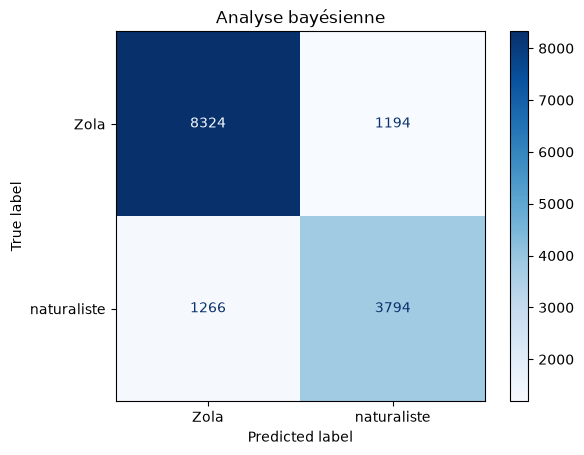

In [120]:
modele_bayes = MultinomialNB(alpha=1)

modele_bayes.fit(X_train_tfidf, y_train)


predictions = modele_bayes.predict(X_test_tfidf)

print(classification_report(y_test, predictions))

cm_bayesien = confusion_matrix(y_test, predictions)
print(cm_bayesien)

ConfusionMatrixDisplay(
    confusion_matrix=cm_bayesien,
    display_labels=modele_bayes.classes_
).plot(cmap="Blues")

plt.title("Analyse bayésienne")
plt.show()

In [121]:
vectorizer = vectorizer
classifieur = modele_bayes

mots = vectorizer.get_feature_names_out()
classes = classifieur.classes_

print("Ordre des classes :", classes)

# Différence des log-probabilités entre les deux classes
score_discriminant = (
    classifieur.feature_log_prob_[0]
    - classifieur.feature_log_prob_[1]
)

resultats_mots = pd.DataFrame({
    "mot": mots,
    f"score_{classes[0]}": score_discriminant
})

# Mots les plus caractéristiques de la première classe
mots_classe_0 = resultats_mots.sort_values(
    f"score_{classes[0]}",
    ascending=False
).head(30)

# Mots les plus caractéristiques de la deuxième classe
mots_classe_1 = resultats_mots.sort_values(
    f"score_{classes[0]}",
    ascending=True
).head(30)

print(f"\nMots les plus caractéristiques de {classes[0]} :")
for _, ligne in mots_classe_0.iterrows():
    print(f"{ligne['mot']:<25} {ligne[f'score_{classes[0]}']:.3f}")

print(f"\nMots les plus caractéristiques de {classes[1]} :")
for _, ligne in mots_classe_1.iterrows():
    print(f"{ligne['mot']:<25} {-ligne[f'score_{classes[0]}']:.3f}")

Ordre des classes : ['Zola' 'naturaliste']

Mots les plus caractéristiques de Zola :
prussiens                 3.178
montsou                   3.028
empereur                  2.931
sedan                     2.906
les prussiens             2.846
coron                     2.839
rasseneur                 2.817
bécu                      2.813
zacharie                  2.784
hubert                    2.784
trouche                   2.776
saget                     2.776
rognes                    2.747
zingueur                  2.745
hourdequin                2.733
chouteau                  2.729
mlle saget                2.702
charbonnel                2.691
insurgés                  2.683
granoux                   2.643
gundermann                2.610
marjolin                  2.609
gueulin                   2.603
boves                     2.593
loubet                    2.592
voreux                    2.589
ramond                    2.588
gagnière                  2.588
marsy              

In [122]:
for mot in ["buteau", "florent", "faujas", "pauline", "coupeau"]:
    nb = df_test["texte"].str.contains(mot, case=False).sum()
    print(mot, nb)

buteau 2
florent 1
faujas 0
pauline 81
coupeau 0


In [123]:
# Utilisation du TF-IDF commun
vectorizer = vectorizer
classifieur = modele_bayes

# Vocabulaire appris sur le train
termes = vectorizer.get_feature_names_out()

# Ordre réel des classes
classes = classifieur.classes_

print("Ordre des classes :", classes)

# X_test_tfidf existe déjà et est commun aux trois modèles

# Transformation du jeu de test avec le vectorizer déjà entraîné
X_test_tfidf = vectorizer.transform(df_test["texte"])

# Nombre d'extraits du test contenant chaque terme
presence_test = np.asarray((X_test_tfidf > 0).sum(axis=0)).ravel()

# Somme des poids TF-IDF de chaque terme dans le test
poids_tfidf_test = np.asarray(X_test_tfidf.sum(axis=0)).ravel()

# Score discriminant appris par Naive Bayes
# score positif : classe 0
# score négatif : classe 1
score_discriminant = (
    classifieur.feature_log_prob_[0]
    - classifieur.feature_log_prob_[1]
)

resultats = pd.DataFrame({
    "terme": termes,
    "score_discriminant": score_discriminant,
    "nb_extraits_test": presence_test,
    "poids_tfidf_test": poids_tfidf_test
})

# On conserve uniquement les termes présents dans le test
resultats_test = resultats[
    resultats["nb_extraits_test"] > 0
].copy()

print(f"\nNombre de termes du vocabulaire présents dans le test : "
      f"{len(resultats_test)}")

Ordre des classes : ['Zola' 'naturaliste']

Nombre de termes du vocabulaire présents dans le test : 9804


In [124]:
n = 30

termes_classe_0 = (
    resultats_test
    .sort_values("score_discriminant", ascending=False)
    .head(n)
)

termes_classe_1 = (
    resultats_test
    .sort_values("score_discriminant", ascending=True)
    .head(n)
)

print(f"\nTermes présents dans le test les plus caractéristiques de {classes[0]} :")

for _, ligne in termes_classe_0.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"score={ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}"
    )

print(f"\nTermes présents dans le test les plus caractéristiques de {classes[1]} :")

for _, ligne in termes_classe_1.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"score={-ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}"
    )


Termes présents dans le test les plus caractéristiques de Zola :
prussiens                 score=3.178  extraits=4
empereur                  score=2.931  extraits=19
les prussiens             score=2.846  extraits=2
hubert                    score=2.784  extraits=1
les camarades             score=2.572  extraits=12
nom dieu                  score=2.565  extraits=56
mineurs                   score=2.458  extraits=1
le pis                    score=2.435  extraits=6
meuse                     score=2.433  extraits=1
charcuterie               score=2.390  extraits=1
jésus christ              score=2.344  extraits=3
clientes                  score=2.344  extraits=3
achevait                  score=2.320  extraits=54
confections               score=2.297  extraits=1
entêtait                  score=2.285  extraits=19
murmura il                score=2.277  extraits=76
dossiers                  score=2.248  extraits=3
fit remarquer             score=2.248  extraits=11
beauce                    s

In [125]:
resultats_test["contribution_test"] = (
    resultats_test["score_discriminant"]
    * resultats_test["poids_tfidf_test"]
)

In [126]:
contributions_zola = (
    resultats_test
    .sort_values("contribution_test", ascending=False)
    .head(30)
)

contributions_naturalistes = (
    resultats_test
    .sort_values("contribution_test", ascending=True)
    .head(30)
)

print(f"\nTermes ayant le plus contribué aux prédictions {classes[0]} :")

for _, ligne in contributions_zola.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"contribution={ligne['contribution_test']:.3f}  "
        f"score={ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}"
    )

print(f"\nTermes ayant le plus contribué aux prédictions {classes[1]} :")

for _, ligne in contributions_naturalistes.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"contribution={-ligne['contribution_test']:.3f}  "
        f"score={-ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}"
    )


Termes ayant le plus contribué aux prédictions Zola :
elle                      contribution=247.872  score=0.371  extraits=6255
qu elle                   contribution=151.817  score=1.372  extraits=1093
ça                        contribution=143.624  score=0.998  extraits=1218
était                     contribution=134.503  score=0.464  extraits=4348
avait                     contribution=124.857  score=0.469  extraits=3933
une                       contribution=94.817  score=0.217  extraits=6317
lorsque                   contribution=78.985  score=1.544  extraits=458
qu                        contribution=76.540  score=0.243  extraits=4734
les                       contribution=72.580  score=0.131  extraits=7216
hein                      contribution=72.045  score=1.679  extraits=217
lorsqu                    contribution=64.900  score=1.172  extraits=511
elle avait                contribution=62.550  score=0.760  extraits=793
ils                       contribution=61.084  score=0.3

## 2. Régression logistique

=== Régression logistique ===
              precision    recall  f1-score   support

        Zola      0.919     0.869     0.893      9518
 naturaliste      0.777     0.855     0.814      5060

    accuracy                          0.864     14578
   macro avg      0.848     0.862     0.854     14578
weighted avg      0.869     0.864     0.866     14578

Matrice de confusion :
[[8274 1244]
 [ 733 4327]]


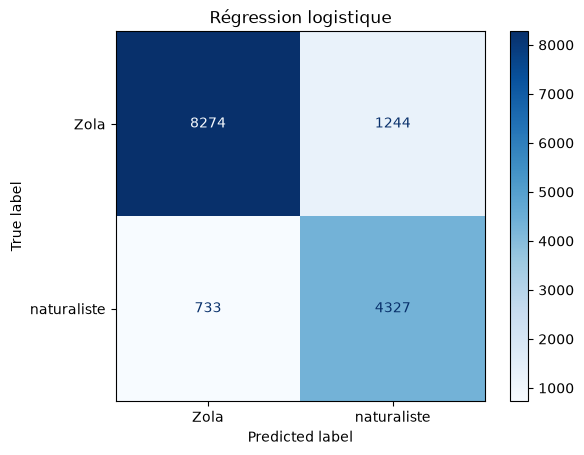

In [127]:
# Entraînement direct, sans Pipeline
modele_logistique = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

modele_logistique.fit(X_train_tfidf, y_train)

predictions_logistiques = modele_logistique.predict(X_test_tfidf)

print("=== Régression logistique ===")
print(classification_report(y_test, predictions_logistiques, digits=3))

cm_logistique = confusion_matrix(y_test, predictions_logistiques)
print("Matrice de confusion :")
print(cm_logistique)

ConfusionMatrixDisplay(
    confusion_matrix=cm_logistique,
    display_labels=modele_logistique.classes_
).plot(cmap="Blues")

plt.title("Régression logistique")
plt.show()

In [128]:
# Termes les plus discriminants de la régression logistique
termes_logistiques = vectorizer.get_feature_names_out()
classes_logistiques = modele_logistique.classes_

print("Ordre des classes :", classes_logistiques)

# En classification binaire :
# - coefficient positif  -> classe classes_[1]
# - coefficient négatif  -> classe classes_[0]
coefficients = modele_logistique.coef_[0]

importance_logistique = pd.DataFrame({
    "terme": termes_logistiques,
    "coefficient": coefficients
})

n = 30

termes_classe_0 = (
    importance_logistique
    .sort_values("coefficient", ascending=True)
    .head(n))

termes_classe_1 = (
    importance_logistique
    .sort_values("coefficient", ascending=False)
    .head(n))

print(f"\nTermes les plus associés à {classes_logistiques[0]} :")
for _, ligne in termes_classe_0.iterrows():
    print(f"{ligne['terme']:<30} {ligne['coefficient']:.4f}")

print(f"\nTermes les plus associés à {classes_logistiques[1]} :")
for _, ligne in termes_classe_1.iterrows():
    print(f"{ligne['terme']:<30} {ligne['coefficient']:.4f}")


Ordre des classes : ['Zola' 'naturaliste']

Termes les plus associés à Zola :
lorsque                        -7.2571
qu elle                        -6.4679
empereur                       -5.9616
ça                             -5.3274
hein                           -4.9842
simplement                     -4.3339
lorsqu                         -4.2325
ce fut                         -4.2053
dut                            -4.0745
ce pas                         -3.9569
tout un                        -3.9350
oncle                          -3.8630
tout suite                     -3.6502
justement                      -3.5997
non non                        -3.5553
finit                          -3.5232
ville                          -3.3790
achevait                       -3.3276
un instant                     -3.3011
travail                        -3.2850
bande                          -3.2600
dames                          -3.2460
nom dieu                       -3.2036
ah bien                  

## 3. Analyse discriminante linéaire

L'analyse discriminante linéaire ne travaille pas directement sur une matrice TF-IDF creuse comportant plusieurs milliers de colonnes. On réduit donc d'abord la dimension avec `TruncatedSVD`, puis on standardise les composantes avant d'entraîner la LDA.

=== Analyse discriminante linéaire ===
Nombre de composantes SVD : 100
Variance expliquée cumulée par la SVD : 0.147
              precision    recall  f1-score   support

        Zola      0.847     0.869     0.858      9518
 naturaliste      0.741     0.706     0.723      5060

    accuracy                          0.812     14578
   macro avg      0.794     0.787     0.790     14578
weighted avg      0.810     0.812     0.811     14578

Matrice de confusion :
[[8268 1250]
 [1490 3570]]


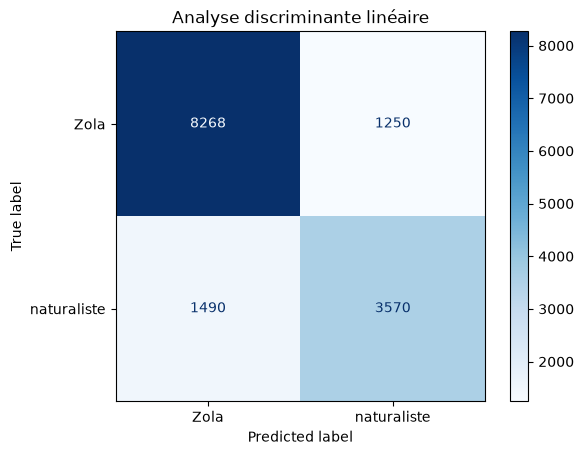

In [129]:
# Nombre de composantes compatible avec la taille réelle des données
n_composantes = min(
    100,
    X_train_tfidf.shape[0] - 1,
    X_train_tfidf.shape[1] - 1)

# Réduction de dimension
svd = TruncatedSVD(
    n_components=n_composantes,
    random_state=42)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

# Standardisation
scaler_lda = StandardScaler()
X_train_lda = scaler_lda.fit_transform(X_train_svd)
X_test_lda = scaler_lda.transform(X_test_svd)

# Analyse discriminante linéaire
modele_lda = LinearDiscriminantAnalysis(solver="svd")
modele_lda.fit(X_train_lda, y_train)

predictions_lda = modele_lda.predict(X_test_lda)

print("=== Analyse discriminante linéaire ===")
print(f"Nombre de composantes SVD : {n_composantes}")
print(
    "Variance expliquée cumulée par la SVD : "
    f"{svd.explained_variance_ratio_.sum():.3f}"
)
print(classification_report(y_test, predictions_lda, digits=3))

cm_lda = confusion_matrix(y_test, predictions_lda)
print("Matrice de confusion :")
print(cm_lda)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lda,
    display_labels=modele_lda.classes_
).plot(cmap="Blues")

plt.title("Analyse discriminante linéaire")
plt.show()


# Comparaison des modèles

In [130]:
comparaison_modeles = pd.DataFrame({
    "modèle": [
        "Analyse bayésienne",
        "Régression logistique",
        "Analyse discriminante linéaire"
    ],

    "accuracy": [
        accuracy_score(y_test, predictions),
        accuracy_score(y_test, predictions_logistiques),
        accuracy_score(y_test, predictions_lda)
    ],

    "f1_macro": [
        f1_score(y_test, predictions, average="macro"),
        f1_score(y_test, predictions_logistiques, average="macro"),
        f1_score(y_test, predictions_lda, average="macro")
    ]
})

comparaison_modeles.sort_values(
    "f1_macro",
    ascending=False
).reset_index(drop=True)

,modèle,accuracy,f1_macro
0,Régression logistique,0.864385,0.853657
1,Analyse bayésienne,0.831253,0.813217
2,Analyse discriminante linéaire,0.812046,0.790263


In [ ]:
X = df_train["texte"].fillna("").to_numpy()
Y = df_train["label"].to_numpy()
groups = df_train["source"].to_numpy()

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Les plis sont calculés une seule fois pour garantir la même
# séparation pour tous les modèles.
plis = list(cv.split(X, Y, groups=groups))


modeles = {
    "Naive Bayes": Pipeline([
        ("tfidf", vectorizer),
        ("clf", MultinomialNB(alpha=1.0))
    ]),

    "Régression logistique": Pipeline([
        ("tfidf", vectorizer),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        ))
    ]),

    "LDA": Pipeline([
        ("tfidf", vectorizer),
        ("svd", TruncatedSVD(
            n_components=100,
            random_state=42
        )),
        ("scaler", StandardScaler()),
        ("clf", LinearDiscriminantAnalysis(
            solver="svd"
        ))
    ])
}

resultats = []

for nom, modele in modeles.items():
    scores = cross_validate(
        modele,
        X,
        Y,
        cv=plis,
        scoring={
            "f1_macro": "f1_macro",
            "accuracy": "accuracy"
        },
        return_train_score=True,
        n_jobs=1  # mettre -1 uniquement si la mémoire disponible le permet
    )

    resultats.append({
        "modèle": nom,
        "F1 macro moyen": scores["test_f1_macro"].mean(),
        "écart-type F1": scores["test_f1_macro"].std(),
        "accuracy moyenne": scores["test_accuracy"].mean(),
        "F1 entraînement": scores["train_f1_macro"].mean()
    })

comparaison_cv = (
    pd.DataFrame(resultats)
    .sort_values("F1 macro moyen", ascending=False)
    .reset_index(drop=True)
)

comparaison_cv

In [ ]:
for numero, (indices_train, indices_validation) in enumerate(plis, start=1):
    sources_train = set(groups[indices_train])
    sources_validation = set(groups[indices_validation])

    intersection = sources_train & sources_validation

    print(
        f"Pli {numero} : "
        f"{len(sources_train)} œuvres train, "
        f"{len(sources_validation)} œuvres validation, "
        f"intersection = {len(intersection)}"
    )

    assert len(intersection) == 0

Pli 1 : 31 œuvres train, 9 œuvres validation, intersection = 0
Pli 2 : 32 œuvres train, 8 œuvres validation, intersection = 0
Pli 3 : 33 œuvres train, 7 œuvres validation, intersection = 0
Pli 4 : 32 œuvres train, 8 œuvres validation, intersection = 0
Pli 5 : 32 œuvres train, 8 œuvres validation, intersection = 0


In [ ]:
pipeline_final = Pipeline([
    ("tfidf", vectorizer),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])

pipeline_final.fit(df_train["texte"], df_train["label"])

probabilites = pipeline_final.predict_proba(df_test["texte"])

classe_zola = list(pipeline_final.classes_).index("Zola")

evaluation_oeuvres = df_test[["source", "label"]].copy()
evaluation_oeuvres["probabilite_zola"] = probabilites[:, classe_zola]

resultats_oeuvres = (
    evaluation_oeuvres
    .groupby("source")
    .agg(
        label_reel=("label", "first"),
        probabilite_zola=("probabilite_zola", "mean")
    )
    .reset_index()
)

resultats_oeuvres["prediction"] = np.where(
    resultats_oeuvres["probabilite_zola"] >= 0.5,
    "Zola",
    "naturaliste"
)

print(
    classification_report(
        resultats_oeuvres["label_reel"],
        resultats_oeuvres["prediction"],
        digits=3
    )
)

resultats_oeuvres

              precision    recall  f1-score   support

        Zola      1.000     1.000     1.000         4
 naturaliste      1.000     1.000     1.000         5

    accuracy                          1.000         9
   macro avg      1.000     1.000     1.000         9
weighted avg      1.000     1.000     1.000         9



,source,label_reel,probabilite_zola,prediction
0,1875_5_La_faute_de_l_abbe_Mouret._clean.txt,Zola,0.756388,Zola
1,1878_8_Une_page_d_amour._clean.txt,Zola,0.738669,Zola
2,1880_9_Nana._clean.txt,Zola,0.750104,Zola
3,1890_17_La_bete_humaine._clean.txt,Zola,0.784565,Zola
4,Charles Demailly.txt,naturaliste,0.241144,naturaliste
5,En ménage.txt,naturaliste,0.298044,naturaliste
6,Frères_Zemganno.txt,naturaliste,0.258193,naturaliste
7,Georgette.txt,naturaliste,0.203258,naturaliste
8,Le_Pere_Goriot.txt,naturaliste,0.227835,naturaliste
